--- Starting Comparison: 18 Scenarios vs LSTM Model ---
Reading Scenarios: E:\Projetos\ABMS-WP\resultados\consumo_previsto_todos_cenarios.csv
Reading LSTM: E:\Projetos\ABMS-WP\modelos IA\previsoes_futuras_2025_2035.csv
Chart successfully saved to: E:\Projetos\ABMS-WP\figuras\comparacao_lstm_18_cenarios_final.pdf


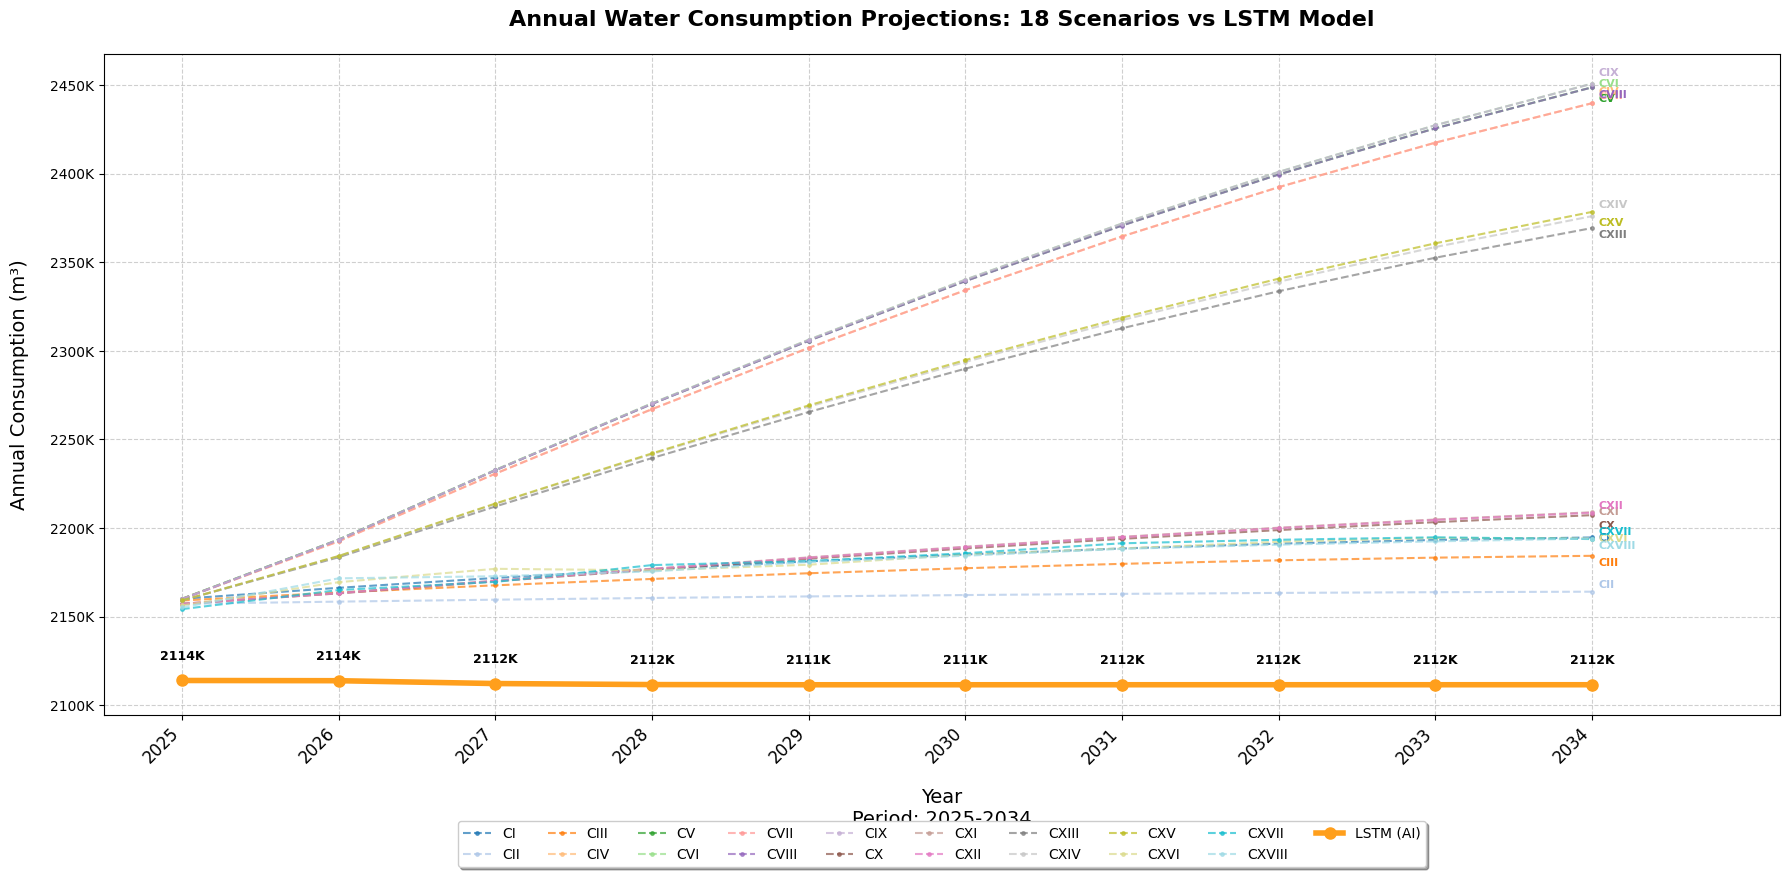

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configuration and Paths
# ==========================================

# Define the base project directory
BASE_PATH = 'E:\\Projetos\\ABM-WP' # Currently active path

# Input Files
# Note: Switching to the 18-scenario file as per instructions
SCENARIO_FILE = 'consumo_previsto_todos_cenarios.csv' 
LSTM_FILE = 'previsoes_futuras_2025_2035.csv'

# Output File
OUTPUT_FILENAME = 'comparacao_lstm_18_cenarios_final.pdf'

# Directory Setup
INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')

def sum_yearly(df, date_col, value_cols):
    """ 
    Helper function to aggregate monthly data into annual sums.
    """
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def main():
    print("--- Starting Comparison: 18 Scenarios vs LSTM Model ---")

    # ==========================================
    # 2. Load Simulation Scenarios Data
    # ==========================================
    
    # Check if file exists in results, otherwise check includes
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios):
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)

    print(f"Reading Scenarios: {path_scenarios}")
    # Using specific separator and decimal for the Brazilian CSV format
    df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')

    # Date Construction
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + 
                                            df_scenarios['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Mes_Ano'], format='%m/%Y')

    # Identify scenario columns (dynamically excludes date/metadata columns)
    metadata_cols = ['Mes', 'Ano', 'Mes_Ano', 'Date']
    scenario_cols = [c for c in df_scenarios.columns if c not in metadata_cols]

    # Filter date range (up to 2034)
    df_scenarios = df_scenarios[df_scenarios['Date'] <= pd.to_datetime('2034-12-31')]

    # ==========================================
    # 3. Load LSTM Prediction Data
    # ==========================================
    
    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    print(f"Reading LSTM: {path_lstm}")
    
    df_lstm = pd.read_csv(path_lstm, parse_dates=['Data'])
    df_lstm = df_lstm.rename(columns={'Data': 'Date', 'Valor Previsto': 'LSTM'})
    df_lstm = df_lstm[df_lstm['Date'] <= pd.to_datetime('2034-12-31')]

    # ==========================================
    # 4. Data Merging and Aggregation
    # ==========================================
    
    # Merge scenarios and LSTM on Date
    df_combined = pd.merge(df_scenarios, df_lstm[['Date', 'LSTM']], on='Date', how='left')

    # Calculate annual sums for all numeric columns
    all_cols = scenario_cols + ['LSTM']
    df_annual = sum_yearly(df_combined, 'Date', all_cols)

    # Define period string for labels
    scenario_period = f"{df_annual['Year'].min()}-{df_annual['Year'].max()}"

    # ==========================================
    # 5. Plotting Configuration
    # ==========================================
    
    plt.figure(figsize=(18, 9))
    ax = plt.gca()

    # Define colormap for the 18 scenarios
    colors = plt.cm.tab20(np.linspace(0, 1, len(scenario_cols)))

    # Cycle of vertical offsets to prevent label overlap at the end of lines
    offset_cycle = [(5, 0), (5, 5), (5, -5), (5, 8), (5, -8)]

    # --- A. Plot Scenarios (Background) ---
    for idx, col in enumerate(scenario_cols):
        # Extract ID (e.g., "CIV" from "CIV_PopUnif_RendaLinear")
        scenario_id = col.split('_')[0]

        ax.plot(df_annual['Year'], df_annual[col],
                color=colors[idx],
                linestyle='--',
                linewidth=1.5,
                marker='.',
                markersize=5,
                alpha=0.7,
                label=scenario_id) # Simplified label for legend
        
        # Direct Labeling: Add ID at the last data point
        last_year = df_annual['Year'].iloc[-1]
        last_val = df_annual[col].iloc[-1]
        current_offset = offset_cycle[idx % len(offset_cycle)]

        if not pd.isna(last_val):
            ax.annotate(scenario_id, 
                        (last_year, last_val), 
                        xytext=current_offset, 
                        textcoords="offset points", 
                        ha='left', va='center',
                        fontsize=8, color=colors[idx], fontweight='bold')

    # --- B. Plot LSTM (Foreground/Highlight) ---
    ax.plot(df_annual['Year'], df_annual['LSTM'],
            color='#FF9F1C', # Bright Orange for high contrast (or Black)
            linestyle='-',
            linewidth=4,
            marker='o',
            markersize=8,
            label='LSTM (AI)',
            zorder=10) # Ensure it stays on top of other lines

    # Add value labels specifically for LSTM points
    for year, val in zip(df_annual['Year'], df_annual['LSTM']):
        if not pd.isna(val):
            ax.annotate(f'{val/1000:.0f}K',
                        (year, val),
                        xytext=(0, 15), 
                        textcoords="offset points",
                        ha='center', fontsize=9, fontweight='bold', color='black')

    # ==========================================
    # 6. Final Formatting
    # ==========================================
    
    # Axis configuration
    ax.set_xticks(df_annual['Year'])
    ax.set_xticklabels(df_annual['Year'], rotation=45, ha='right', fontsize=12)
    
    # Y-Axis K-formatting function
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

    # Set Limits (Add extra space on the right for text labels)
    ax.set_xlim(df_annual['Year'].min() - 0.5, df_annual['Year'].max() + 1.2)

    # Labels and Title
    ax.set_xlabel(f"Year\nPeriod: {scenario_period}", fontsize=14, labelpad=15)
    ax.set_ylabel('Annual Consumption (m³)', fontsize=14, labelpad=15)
    plt.title('Annual Water Consumption Projections: 18 Scenarios vs LSTM Model', 
              fontsize=16, pad=20, fontweight='bold')

    # Grid and Layout
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Legend at the footer
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
               ncol=10, fancybox=True, shadow=True, fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2) # Adjust margin for footer legend

    # ==========================================
    # 7. Saving Output
    # ==========================================
    
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
        print(f"Created directory: {OUTPUT_DIR}")

    full_output_path = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
    plt.savefig(full_output_path, format='pdf', bbox_inches='tight')
    
    print(f"Chart successfully saved to: {full_output_path}")
    plt.show()

if __name__ == "__main__":
    main()